# LLM (Parametric Knowledge Flow)
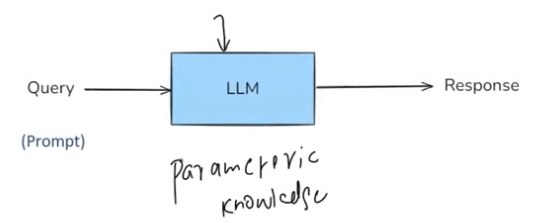
LLM processes it using **parametric knowledge** (knowledge stored in model weights)
# Why RAG? (Retrieval-Augmented Generation)

- LLMs have **limited parametric knowledge**
- Cannot access **recent data or private data**
- May generate **hallucinated answers**

# How can we solve above problem to some Extent-Fine-Tuning
- Training an LLM on custom data  
- Adjusts model weights  
- Improves domain-specific performance  
- Makes responses more accurate for specific tasks

## Example

If you fine-tune a model on **medical reports**,  
it becomes better at:

- Understanding medical terminology  
- Generating accurate clinical summaries  
- Answering healthcare-related questions  

Example:

Query: "What are symptoms of diabetes?"  
Fine-tuned medical model → More precise and domain-aware answer  
## Fine-Tuning Steps (Short)

1. **Collect Data** – Prepare prompt → desired output examples  
2. **Choose Method** – Full FT or LoRA / QLoRA  
3. **Train Model** – Update all or partial weights  
4. **Evaluate** – Check accuracy, factuality, hallucinations

## Problems with Fine-Tuning

- Requires large, high-quality training data  
- Expensive (compute + time)  
- Technical Expertise

# Another Way - In-Context Learning (ICL)

Model learns from examples **inside the prompt**  
No weight updates required  

## Small Example

Prompt:

Translate English to French:

Dog → Chien  
Cat → Chat  
Car → ?

Response:
Voiture  

The model understands the pattern from examples and applies it.
# In-Context Learning (ICL) as an Emergent Property

- **Emergent property** = A behavior that appears when a system becomes large/complex enough  
- Not explicitly programmed  
- Appears at scale  

Large models like **GPT-3 / GPT-4** show strong in-context learning ability  
Earlier models like **GPT-1 and GPT-2** did not show this capability clearly  

---

# From ICL → RAG

Instead of giving only small task examples, we can:

- Retrieve background information  
- Fetch facts, documents, manuals  
- Inject that information into the prompt  
- Augment the model’s knowledge at runtime  

---

# Example RAG Prompt Template
```python
You are a helpful assistant.
Answer the question ONLY from the provided context.
If the context is insufficient, just say you don't know.

{context}
Question: {question}
```

# RAG = Information Retrival + Text Generation
RAG is a way to make a language model (like ChatGPT) smarter by giving it extra information at the time you ask your question.
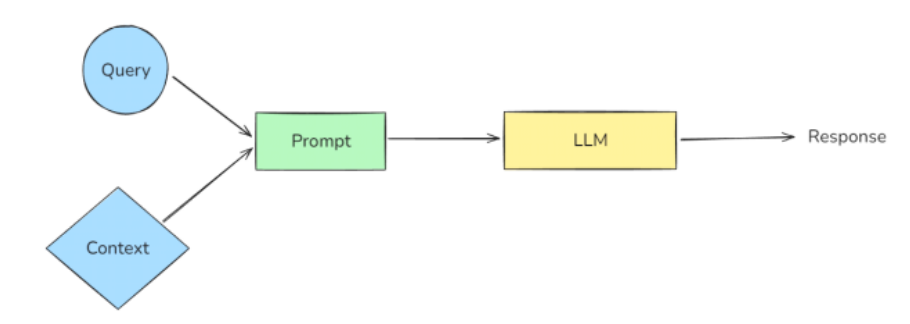

## RAG involves 4 things-
1. Indexing
2. Retrieval
3. Augmentation
4. Generation

## Indexing (RAG Step 1)

**Indexing** is the process of preparing your knowledge base so it can be efficiently searched at query time.  
It consists of multiple sub-steps.

---

### 1️⃣ Document Ingestion

Load your source knowledge into memory.

#### 📂 Examples
- PDF reports, Word documents  
- YouTube transcripts, blog pages  
- GitHub repositories, internal wikis  
- SQL records, scraped webpages
#### Tools
🛠️ **Tools:** LangChain loaders like `PyPDFLoader`, `YoutubeLoader`, `WebBaseLoader`, `GitLoader`, and SQL/custom loaders.

### 2️⃣ Text Chunking

Break large documents into small, semantically meaningful chunks.

**Why?**
- LLMs have context limits (4K–32K tokens)
- Smaller chunks improve semantic search accuracy

**Tools:**
`RecursiveCharacterTextSplitter`, `MarkdownHeaderTextSplitter`, `SemanticChunker`

### 3️⃣ Embedding Generation

Convert each chunk into a dense vector (embedding) that captures its meaning.

**Why?**
- Similar ideas are close in vector space  
- Enables fast semantic (fuzzy) search  

**Tools:**
`OpenAIEmbeddings`, `SentenceTransformerEmbeddings`, `InstructorEmbeddings`

### 4️⃣ Storage in Vector Store

Store embeddings along with original chunk text and metadata in a vector database.

**Vector DB Options:**
- **Local:** FAISS, Chroma  
- **Cloud:** Pinecone, Weaviate, Milvus  

## Retrieval (RAG Step 2)

**Retrieval** is the real-time process of selecting the most relevant chunks  
from the indexed knowledge base based on the user’s query.

- Done using Semantic Search -> Take top k
It is like asking:

> “From all available knowledge, which 3–5 chunks best answer this question?”

## Augmentation (RAG Step 3)

**Augmentation** combines the retrieved context with the user’s query  
to create an enriched prompt for the LLM.

### Example Prompt Template

```text
You are a helpful assistant.
Answer the question ONLY from the provided context.
If the context is insufficient, just say you don't know.

{context}
Question: {question}
```
## Generation (RAG Step 4)
Generate output for Prompt + Context
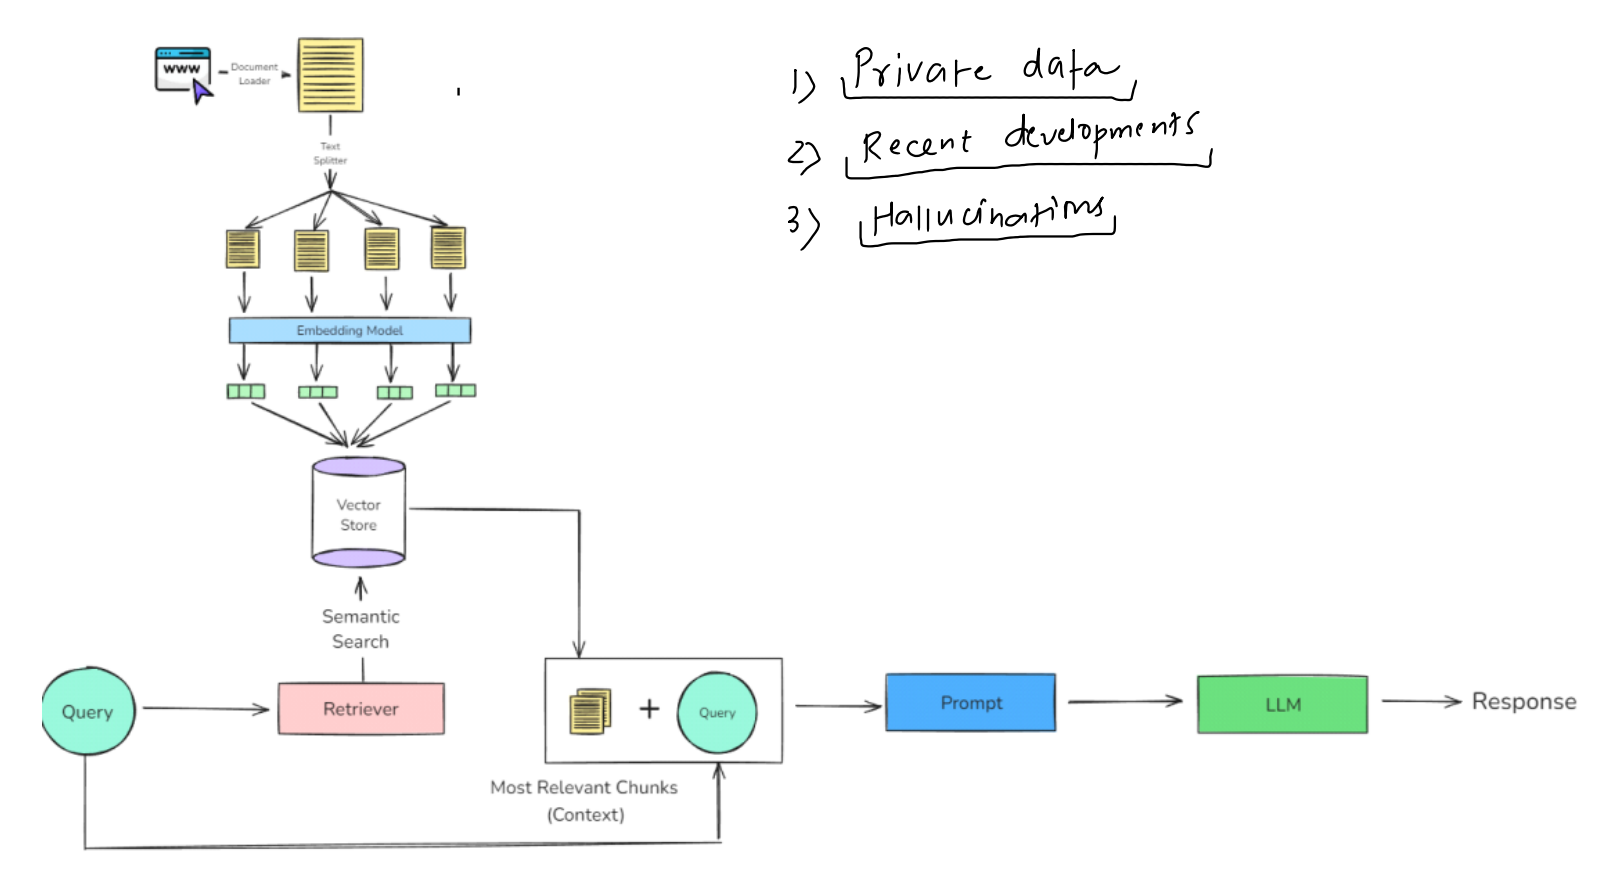

## How RAG Solves LLM Limitations

- **Private Data:** Retrieves and uses your internal documents at query time.  
- **Recent Information:** Fetches up-to-date data instead of relying only on training data.  
- **Hallucinations:** Grounds answers in retrieved facts, reducing made-up responses.

 
# 🚀 Improving RAG (Retrieval-Augmented Generation)

## 1️⃣ UI Enhancements
- Show retrieved chunks
- Highlight citations
- Add feedback (👍 / 👎)
- Display confidence score

---

## 2️⃣ Evaluation
### a) Ragas
- Context Precision
- Context Recall
- Faithfulness
- Answer Relevancy

### b) LangSmith
- Trace debugging
- Monitor latency & tokens
- Compare prompts/models

---

## 3️⃣ Indexing
### a) Document Ingestion
- Clean & normalize text
- Remove duplicates
- Add metadata

### b) Text Splitting
- Use RecursiveCharacterTextSplitter
- Maintain 10–20% overlap
- Prefer semantic splitting

### c) Vector Store
- Use good embeddings
- Enable metadata filtering
- Support hybrid search (Dense + BM25)

---

## 4️⃣ Retrieval

### 🔹 Pre-Retrieval
- Query rewriting (LLM)
- Multi-query generation
- Domain-aware routing

### 🔹 During Retrieval
- MMR (reduce redundancy)
- Hybrid retrieval
- Reranking (cross-encoder)

### 🔹 Post-Retrieval
- Contextual compression
- Remove irrelevant sentences

---

## 5️⃣ Augmentation
- Prompt templating
- Answer grounding
- Context window optimization

---

## 6️⃣ Generation
- Answer with citations
- **Guard Railing** (reduce hallucination)

---

## 7️⃣ System Design
- Multimodal RAG
- Agentic RAG
- Memory-based personalization

---
